In [ ]:
# Project path setup after moving notebooks into notebooks/
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


In [1]:
# Cell 1: 严格按照 VRB 论文 - 使用原生接触状态
# ============================================================
# 作用：生成“按论文定义”的接触帧样本组。
#
# 输出变量：
#   paper_t_contact / paper_active_hand
#       论文式第一接触帧，等价于原来的 t_contact / active_hand。
#   paper_first_contact_sample
#       当前视频/片段的论文式第一接触帧。
#   paper_pipeline_samples
#       严格按论文入口进入后续 pipeline 的样本组。
#       当前 notebook 只处理一个视频，所以这个列表通常只有 1 个样本。
#       以后跨多个视频批量时，每个视频追加一个 paper_first_contact_sample。
#   paper_positive_contact_samples
#       所有平滑后为 contact 的帧，仅用于诊断，不建议直接当作论文式批量入口。
# ============================================================

import numpy as np
from scipy.signal import savgol_filter
from pathlib import Path
from epic_kitchens.hoa import load_detections
from epic_kitchens.hoa.types import HandState


def make_pipeline_sample(frame, hand, source, note='', **extra):
    """统一后续 pipeline 的样本格式。frame 是 0-based 帧号。"""
    sample = {
        'frame': int(frame),
        'hand': str(hand).lower(),
        'source': source,
        'note': note,
    }
    sample.update(extra)
    return sample


# 读取 100 DOH 标注文件
anno_path = Path('data/P01_109.pkl')
print(f'Loading annotations from {anno_path}...')
detections = load_detections(str(anno_path))
num_frames = len(detections)
print(f'Total frames: {num_frames}')
print(f'Cell 1 进入流程帧数: {num_frames}')

# 初始化左右手接触变量
left_contact = np.zeros(num_frames)
right_contact = np.zeros(num_frames)
left_hand_bboxes = [None] * num_frames
right_hand_bboxes = [None] * num_frames

# 遍历每一帧，提取原生接触状态
print('Extracting contact states...')
for frame_idx in range(num_frames):
    frame_det = detections[frame_idx]

    if hasattr(frame_det, 'hands'):
        for hand in frame_det.hands:
            if hand.score > 0.5:
                bbox = [hand.bbox.left, hand.bbox.top, hand.bbox.right, hand.bbox.bottom]

                # 判断接触状态：PORTABLE_OBJECT(3) 或 STATIONARY_OBJECT(4)
                is_contact = hand.state in [HandState.PORTABLE_OBJECT, HandState.STATIONARY_OBJECT]
                contact_value = 1 if is_contact else 0

                # 根据手的侧别记录
                if hand.side.name == 'LEFT':
                    left_hand_bboxes[frame_idx] = bbox
                    left_contact[frame_idx] = contact_value
                elif hand.side.name == 'RIGHT':
                    right_hand_bboxes[frame_idx] = bbox
                    right_contact[frame_idx] = contact_value

print(f'Left hand contact frames: {int(np.sum(left_contact))}')
print(f'Right hand contact frames: {int(np.sum(right_contact))}')

# 应用 Savitzky-Golay 滤波（严格遵循论文参数）
print('Applying Savitzky-Golay filter...')
left_smooth = savgol_filter(left_contact, window_length=7, polyorder=2)
right_smooth = savgol_filter(right_contact, window_length=7, polyorder=2)

# 阈值判定（0.75）
left_binary = (left_smooth > 0.75).astype(int)
right_binary = (right_smooth > 0.75).astype(int)

# 找到论文式接触帧
left_indices = np.where(left_binary == 1)[0]
right_indices = np.where(right_binary == 1)[0]

# 诊断用：所有平滑后为 contact 的帧。
# 注意：论文训练样本入口通常取每个视频/片段的第一接触帧，不是把这些正帧全当作样本。
paper_positive_contact_samples = []
for idx in left_indices:
    paper_positive_contact_samples.append(make_pipeline_sample(idx, 'left', 'paper_positive_contact', 'Diagnostic: smoothed contact > 0.75'))
for idx in right_indices:
    paper_positive_contact_samples.append(make_pipeline_sample(idx, 'right', 'paper_positive_contact', 'Diagnostic: smoothed contact > 0.75'))
paper_positive_contact_samples = sorted(
    paper_positive_contact_samples,
    key=lambda s: (s['frame'], 0 if s['hand'] == 'left' else 1),
)

# 判断哪只手先接触（Active Hand），保持论文式第一接触帧定义。
if len(left_indices) > 0 and len(right_indices) > 0:
    if left_indices[0] < right_indices[0]:
        t_contact = int(left_indices[0])
        active_hand = 'left'
    else:
        t_contact = int(right_indices[0])
        active_hand = 'right'
elif len(left_indices) > 0:
    t_contact = int(left_indices[0])
    active_hand = 'left'
elif len(right_indices) > 0:
    t_contact = int(right_indices[0])
    active_hand = 'right'
else:
    t_contact = None
    active_hand = None
    print('No contact detected!')

# 保存一份不会被后续 Cell 覆盖的论文式结果。
paper_t_contact = t_contact
paper_active_hand = active_hand
paper_first_contact_sample = None
if paper_t_contact is not None:
    paper_first_contact_sample = make_pipeline_sample(
        paper_t_contact,
        paper_active_hand,
        'paper_first_contact',
        'First contact frame selected by the paper-style contact rule',
    )

# 后续 Cell 2 的 paper 模式使用这个列表。
# 当前 notebook 只对应一个视频/片段，所以严格论文入口只有一个样本。
paper_pipeline_samples = [] if paper_first_contact_sample is None else [paper_first_contact_sample]

print('=' * 80)
print('Cell 1 论文式 contact frame 结果')
print('=' * 80)
print(f'paper_pipeline_samples: {len(paper_pipeline_samples)}')
print(f'paper_positive_contact_samples (diagnostic only): {len(paper_positive_contact_samples)}')
if paper_first_contact_sample is not None:
    print(f'✓ paper_t_contact = {paper_t_contact}')
    print(f'✓ paper_active_hand = {paper_active_hand}')
    print(f'✓ image file = frame_{paper_t_contact + 1:010d}.jpg')
else:
    print('未检测到论文式 contact frame')


Loading annotations from data/P01_109.pkl...
Total frames: 185406
Cell 1 进入流程帧数: 185406
Extracting contact states...
Left hand contact frames: 142556
Right hand contact frames: 150671
Applying Savitzky-Golay filter...
Cell 1 论文式 contact frame 结果
paper_pipeline_samples: 1
paper_positive_contact_samples (diagnostic only): 284643
✓ paper_t_contact = 6
✓ paper_active_hand = right
✓ image file = frame_0000000007.jpg


In [2]:
# Cell 1-测试: 扫描有物体检测的接触帧，并评估哪些样本可继续进入 pipeline
# ============================================================
# 作用：生成“筛选过的可跑样本组”。
#
# 它不是论文 contact frame 的定义，而是工程质量筛选：
#   1. 手部状态为 PORTABLE_OBJECT 或 STATIONARY_OBJECT（人工标注的接触）
#   2. 该帧存在物体检测框（score > 0.5）
#   3. 使用增强版 contact point 提取：
#      hand skin edge -> active object bbox -> object visible boundary band -> project to object boundary
#   4. 最终 projected contact points >= 5 才进入 filtered_pipeline_samples
#
# 输出变量：
#   filtered_pipeline_samples / scan_candidates
#       已经通过 contact point 提取筛选的样本组，适合先批量跑通 pipeline。
#   recommended_sample
#       filtered_pipeline_samples[0]，只用于单样本快速调试。
#   scan_failures
#       有接触标注但没有通过 contact point 提取的样本，便于分析阈值问题。
# ============================================================

from epic_kitchens.hoa.types import HandState
import numpy as np
import cv2
from pathlib import Path

from vrbreproduction.contact_point_utils import (
    ContactExtractionConfig,
    extract_contact_points,
    get_valid_object_bboxes,
)

# 批量扫描上限。需要扫完整视频时改成 num_frames。
scan_limit = 500
frames_dir = Path('data/P01_109_frames')

# 这组参数决定 contact point 提取是否严格。
# boundary_distance_px 越大，越容易通过；越小，越贴近物体可见边界。
contact_extraction_config = ContactExtractionConfig(
    use_object_mask=True,
    use_object_boundary=True,
    boundary_distance_px=6.0,
    project_points_to_object_boundary=True,
)


def count_contact_points_for_candidate(frame_idx, hand_bbox, object_bboxes):
    frame_path = frames_dir / f'frame_{frame_idx + 1:010d}.jpg'
    img = cv2.imread(str(frame_path))
    if img is None:
        return {
            'status': 'missing_frame',
            'skin_pixels': 0,
            'edge_pixels': 0,
            'raw_bbox_contact_points': 0,
            'candidate_hand_edge_points': 0,
            'contact_points': 0,
            'active_object_bbox': None,
        }

    extraction = extract_contact_points(
        img,
        hand_bbox,
        object_bboxes,
        config=contact_extraction_config,
    )
    contact_count = int(len(extraction['contact_points']))
    status = 'valid' if contact_count >= 5 else 'discard_contact_points'
    return {
        'status': status,
        'skin_pixels': extraction['skin_pixels'],
        'edge_pixels': extraction['edge_pixels'],
        'raw_bbox_contact_points': int(len(extraction['raw_bbox_contact_points'])),
        'candidate_hand_edge_points': int(len(extraction['candidate_hand_edge_points'])),
        'contact_points': contact_count,
        'active_object_bbox': extraction['active_object_bbox'],
    }


scan_summary = {
    'scanned_frames': min(scan_limit, num_frames),
    'contact_with_object_frames': 0,
    'valid': 0,
    'discard_contact_points': 0,
    'missing_frame': 0,
}
scan_candidates = []
scan_failures = []
scan_candidate_rank = {}

for frame_idx in range(min(scan_limit, num_frames)):
    frame_det = detections[frame_idx]
    object_bboxes = get_valid_object_bboxes(
        frame_det,
        score_threshold=contact_extraction_config.object_score_threshold,
    )
    if len(object_bboxes) == 0:
        continue

    for hand in frame_det.hands:
        if hand.score > contact_extraction_config.hand_score_threshold and hand.state in [HandState.PORTABLE_OBJECT, HandState.STATIONARY_OBJECT]:
            side = hand.side.name.lower()
            hand_bbox = [hand.bbox.left, hand.bbox.top, hand.bbox.right, hand.bbox.bottom]
            metrics = count_contact_points_for_candidate(frame_idx, hand_bbox, object_bboxes)
            record = {
                'frame': int(frame_idx),
                'hand': side,
                'source': 'filtered_contact_points',
                'note': 'Contact frame that passed contact point extraction precheck',
                'num_objects': len(object_bboxes),
                'hand_bbox': hand_bbox,
                'active_object_bbox': metrics['active_object_bbox'],
                'status': metrics['status'],
                'skin_pixels': metrics['skin_pixels'],
                'edge_pixels': metrics['edge_pixels'],
                'raw_bbox_contact_points': metrics['raw_bbox_contact_points'],
                'candidate_hand_edge_points': metrics['candidate_hand_edge_points'],
                'contact_points': metrics['contact_points'],
            }
            scan_summary['contact_with_object_frames'] += 1
            scan_summary[metrics['status']] += 1
            if metrics['status'] == 'valid':
                scan_candidates.append(record)
            else:
                scan_failures.append(record)
            break

print('=' * 80)
print('Cell 1-测试 扫描统计')
print('=' * 80)
print('Cell 1-测试 进入流程帧数: {}'.format(scan_summary['scanned_frames']))
print('扫描帧数: {}'.format(scan_summary['scanned_frames']))
print('候选接触帧（有手接触且有物体框）: {}'.format(scan_summary['contact_with_object_frames']))
print('可继续进入 pipeline 的帧: {}'.format(scan_summary['valid']))
print('因 contact points 不足被丢弃的帧: {}'.format(scan_summary['discard_contact_points']))
print('因图像缺失被跳过的帧: {}'.format(scan_summary['missing_frame']))
if scan_summary['contact_with_object_frames'] > 0:
    keep_rate = scan_summary['valid'] / scan_summary['contact_with_object_frames']
    discard_rate = (scan_summary['discard_contact_points'] + scan_summary['missing_frame']) / scan_summary['contact_with_object_frames']
    print('候选帧保留率: {:.1%}'.format(keep_rate))
    print('候选帧丢弃率: {:.1%}'.format(discard_rate))

print('接触点提取参数:')
print('  use_object_mask: {}'.format(contact_extraction_config.use_object_mask))
print('  use_object_boundary: {}'.format(contact_extraction_config.use_object_boundary))
print('  boundary_distance_px: {}'.format(contact_extraction_config.boundary_distance_px))
print('  project_points_to_object_boundary: {}'.format(contact_extraction_config.project_points_to_object_boundary))

print('可继续进入 pipeline 的前 10 个样本:')
print('{:>6}  {:>6}  {:>6}  {:>8}  {:>8}  {:>8}  {:>8}  {:>10}'.format('帧号', '手', '物体数', 'skin', 'edge', 'raw', 'near', 'contact'))
print('-' * 92)
for info in scan_candidates[:10]:
    print('{:>6}  {:>6}  {:>6}  {:>8}  {:>8}  {:>8}  {:>8}  {:>10}'.format(
        info['frame'], info['hand'], info['num_objects'], info['skin_pixels'], info['edge_pixels'],
        info['raw_bbox_contact_points'], info['candidate_hand_edge_points'], info['contact_points']))

print('被丢弃的前 10 个样本:')
print('{:>6}  {:>6}  {:>6}  {:>24}  {:>8}  {:>8}  {:>8}  {:>8}  {:>10}'.format('帧号', '手', '物体数', '状态', 'skin', 'edge', 'raw', 'near', 'contact'))
print('-' * 120)
for info in scan_failures[:10]:
    print('{:>6}  {:>6}  {:>6}  {:>24}  {:>8}  {:>8}  {:>8}  {:>8}  {:>10}'.format(
        info['frame'], info['hand'], info['num_objects'], info['status'], info['skin_pixels'], info['edge_pixels'],
        info['raw_bbox_contact_points'], info['candidate_hand_edge_points'], info['contact_points']))

for idx, record in enumerate(scan_candidates):
    scan_candidate_rank[(record['frame'], record['hand'])] = idx + 1

print('可进入后续 pipeline 的所有样本序号:')
if len(scan_candidates) == 0:
    print('  None')
else:
    print('{:>6}  {:>6}  {:>6}  {:>10}'.format('序号', '帧号', '手', 'contact'))
    print('-' * 36)
    for idx, info in enumerate(scan_candidates):
        print('{:>6}  {:>6}  {:>6}  {:>10}'.format(
            idx,
            info['frame'],
            info['hand'],
            info['contact_points'],
        ))

# 后续 Cell 2/批量循环使用这个名字，语义比 scan_candidates 更清楚。
filtered_pipeline_samples = scan_candidates
recommended_sample = filtered_pipeline_samples[0] if len(filtered_pipeline_samples) > 0 else None

if recommended_sample is not None:
    print('自动推荐继续进入 pipeline 的样本: frame {}, hand={}, contact_points={}'.format(recommended_sample['frame'], recommended_sample['hand'], recommended_sample['contact_points']))
    print('推荐样本在可用候选中的排序: 1/{}'.format(len(filtered_pipeline_samples)))
else:
    print('未找到可继续进入 pipeline 的样本，建议增大 scan_limit 或检查数据/阈值')


Cell 1-测试 扫描统计
Cell 1-测试 进入流程帧数: 500
扫描帧数: 500
候选接触帧（有手接触且有物体框）: 386
可继续进入 pipeline 的帧: 375
因 contact points 不足被丢弃的帧: 11
因图像缺失被跳过的帧: 0
候选帧保留率: 97.2%
候选帧丢弃率: 2.8%
接触点提取参数:
  use_object_mask: True
  use_object_boundary: True
  boundary_distance_px: 6.0
  project_points_to_object_boundary: True
可继续进入 pipeline 的前 10 个样本:
    帧号       手     物体数      skin      edge       raw      near     contact
--------------------------------------------------------------------------------------------
    72    left       1       652       224        94        71          71
    73    left       1       592       245        76        76          76
    74    left       1       737       236       119       119         119
    75    left       1       792       254       149       127         127
    76    left       1       850       233       141        86          86
    77    left       1       831       178       110       107         107
    78    left       1       891       186       113       109 

Cell 2 进入流程帧数: 375
Cell 2 当前样本
样本选择模式: filtered[0]
当前样本组大小: 375
当前样本 source: filtered_contact_points
当前样本 note: Contact frame that passed contact point extraction precheck
Cell 1-测试推荐样本: frame 72, hand=left, contact_points=71
Cell 1 论文式第一接触样本: frame 6, hand=right
当前进入 Cell 2 的样本: frame 72, hand=left
扫描阶段预估: status=valid, skin=652, edge=224, raw=94, near=71, contact=71
当前样本在可用候选中的排序: 1/375
Processing frame 72
Frame path: data/P01_109_frames/frame_0000000073.jpg
Image size: 456x256
Active hand bbox: [0.3333333432674408, 0.7890625, 0.4035087823867798, 0.953125]
Objects: 1
  Hand (pixels): x1=152, y1=202, x2=184, y2=244
  Object 0 (pixels): x1=168, y1=143, x2=250, y2=235
  Skin pixels in hand bbox: 652
  Edge pixels: 224
  Active object bbox intersection: x=[169,184], y=[202,235]
  Raw bbox contact candidates: 94
  Near object-boundary hand-edge candidates: 71
  Final projected contact points for GMM: 71
  Object mask pixels: 5140
  Object boundary band pixels: 5116
Contact points found: 7

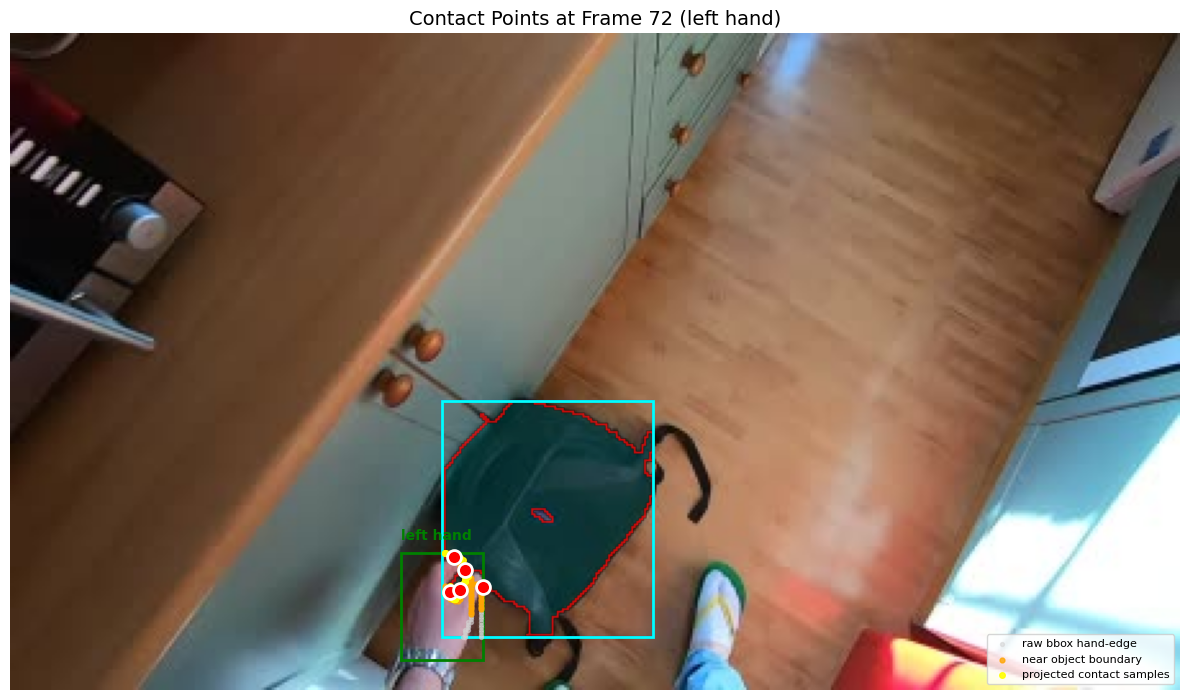

In [4]:
# Cell 2: 读取 t_contact 帧并提取接触点
# ============================================================
# 本 Cell 是后续 Cell 3/4 的单样本入口。
#
# 你现在可以从三类样本组中选择一个样本进入后续 pipeline：
#   1. pipeline_input_mode = 'manual'
#      手动指定样本。用于调试某一帧或少量指定帧。
#      修改 manual_pipeline_samples 即可。
#
#   2. pipeline_input_mode = 'filtered'
#      使用 Cell 1-测试生成的 filtered_pipeline_samples。
#      这些帧已经通过 contact point >= 5 的预筛选，最适合先批量跑通工程流程。
#
#   3. pipeline_input_mode = 'paper'
#      使用 Cell 1 生成的 paper_pipeline_samples。
#      当前 notebook 中它是论文式第一接触帧；不做 contact point 预筛选。
#      严格按论文定义批量处理时用它；失败样本会在 Cell 2/3 中标记 discard。
#
# 当前 Cell 仍然一次只处理一个样本：
#   pipeline_sample_index = 0  表示取当前样本组的第 1 个样本。
# 后面做真正批量处理时，会循环 pipeline_samples 这个列表。
# ============================================================
# Cell 2 现在图里的点含义是：
#   - 灰色：原始 hand edge ∩ object bbox 候选点
#   - 橙色：距离可见物体边界足够近的 hand-edge 候选点
#   - 黄色：投影到最近物体边界后的最终 contact samples
#   - 红点：这批黄色点拟合出来的 GMM means，也就是后续 heatmap 的中心

%matplotlib inline
import cv2
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from pathlib import Path
import numpy as np

from vrbreproduction.contact_point_utils import (
    ContactExtractionConfig,
    extract_contact_points,
    get_active_hand_bbox,
    get_valid_object_bboxes,
)

discard = False
discard_reason = None

# ---- 样本组选择区：只改这里就能切换后续 pipeline 的入口 ----
# 可选值：'manual' / 'filtered' / 'paper'
pipeline_input_mode = 'filtered'

# 当前只跑样本组中的第几个样本。0 表示第一个。
pipeline_sample_index = 0

# 手动样本组：可以只放一个样本，也可以放多个样本。
# frame 是 0-based 帧号；对应图片文件是 frame_{frame + 1:010d}.jpg。
manual_pipeline_samples = [
    {'frame': 72, 'hand': 'left', 'source': 'manual_debug', 'note': 'Current debug sample'},
    # {'frame': 73, 'hand': 'left', 'source': 'manual_debug'},
]


def normalize_pipeline_sample(sample, default_source):
    """把手动 tuple/dict 或扫描结果统一成 {'frame', 'hand', 'source'} 格式。"""
    if isinstance(sample, dict):
        normalized = dict(sample)
        frame = normalized.get('frame', normalized.get('t_contact'))
        hand = normalized.get('hand', normalized.get('active_hand'))
    else:
        frame, hand = sample[:2]
        normalized = {}

    if frame is None or hand is None:
        raise ValueError('pipeline sample 必须包含 frame 和 hand: {}'.format(sample))

    normalized['frame'] = int(frame)
    normalized['hand'] = str(hand).lower()
    normalized.setdefault('source', default_source)
    normalized.setdefault('note', '')
    return normalized


def get_pipeline_samples(mode):
    """根据入口模式返回样本组。后续批量处理也会循环这个列表。"""
    if mode == 'manual':
        samples = manual_pipeline_samples
        default_source = 'manual'
    elif mode == 'filtered':
        if 'filtered_pipeline_samples' in globals():
            samples = filtered_pipeline_samples
        elif 'scan_candidates' in globals():
            samples = scan_candidates
        else:
            raise RuntimeError('filtered 模式需要先运行 Cell 1-测试，生成 filtered_pipeline_samples/scan_candidates')
        default_source = 'filtered_contact_points'
    elif mode == 'paper':
        if 'paper_pipeline_samples' not in globals():
            raise RuntimeError('paper 模式需要先运行 Cell 1，生成 paper_pipeline_samples')
        samples = paper_pipeline_samples
        default_source = 'paper_first_contact'
    else:
        raise ValueError("pipeline_input_mode 只能是 'manual'、'filtered' 或 'paper'，当前为 {}".format(mode))

    normalized_samples = [normalize_pipeline_sample(sample, default_source) for sample in samples]
    if len(normalized_samples) == 0:
        raise RuntimeError('{} 模式下没有可用样本'.format(mode))
    return normalized_samples


pipeline_samples = get_pipeline_samples(pipeline_input_mode)
print('Cell 2 进入流程帧数: {}'.format(len(pipeline_samples)))
if pipeline_sample_index < 0 or pipeline_sample_index >= len(pipeline_samples):
    raise IndexError('pipeline_sample_index={} 超出样本组范围，当前样本数={}'.format(pipeline_sample_index, len(pipeline_samples)))

current_pipeline_sample = pipeline_samples[pipeline_sample_index]
t_contact = current_pipeline_sample['frame']
active_hand = current_pipeline_sample['hand']
selection_mode = '{}[{}]'.format(pipeline_input_mode, pipeline_sample_index)

contact_extraction_config = globals().get(
    'contact_extraction_config',
    ContactExtractionConfig(
        use_object_mask=True,
        use_object_boundary=True,
        boundary_distance_px=6.0,
        project_points_to_object_boundary=True,
    )
)

print('=' * 80)
print('Cell 2 当前样本')
print('=' * 80)
print('样本选择模式: {}'.format(selection_mode))
print('当前样本组大小: {}'.format(len(pipeline_samples)))
print('当前样本 source: {}'.format(current_pipeline_sample.get('source', 'n/a')))
if current_pipeline_sample.get('note'):
    print('当前样本 note: {}'.format(current_pipeline_sample['note']))
if 'recommended_sample' in globals() and recommended_sample is not None:
    print('Cell 1-测试推荐样本: frame {}, hand={}, contact_points={}'.format(recommended_sample['frame'], recommended_sample['hand'], recommended_sample['contact_points']))
if 'paper_first_contact_sample' in globals() and paper_first_contact_sample is not None:
    print('Cell 1 论文式第一接触样本: frame {}, hand={}'.format(paper_first_contact_sample['frame'], paper_first_contact_sample['hand']))
print('当前进入 Cell 2 的样本: frame {}, hand={}'.format(t_contact, active_hand))

selected_scan_record = None
if 'scan_candidates' in globals() and 'scan_failures' in globals():
    for record in scan_candidates + scan_failures:
        if record['frame'] == t_contact and record['hand'] == active_hand:
            selected_scan_record = record
            break

selected_sample_rank = None
if 'scan_candidate_rank' in globals():
    selected_sample_rank = scan_candidate_rank.get((t_contact, active_hand))

if selected_scan_record is not None:
    print('扫描阶段预估: status={}, skin={}, edge={}, raw={}, near={}, contact={}'.format(
        selected_scan_record['status'], selected_scan_record['skin_pixels'], selected_scan_record['edge_pixels'],
        selected_scan_record.get('raw_bbox_contact_points', 'n/a'),
        selected_scan_record.get('candidate_hand_edge_points', 'n/a'),
        selected_scan_record['contact_points']))
    if selected_sample_rank is not None and 'scan_candidates' in globals():
        print('当前样本在可用候选中的排序: {}/{}'.format(selected_sample_rank, len(scan_candidates)))
    else:
        print('当前样本在扫描阶段不会进入 filtered_pipeline_samples（status={}）'.format(selected_scan_record['status']))
else:
    print('扫描阶段预估: 当前样本不在 Cell 1-测试扫描结果中（可能未运行 Cell 1-测试、超出 scan_limit，或来自 paper/manual 模式）')

# 读取 t_contact 帧
frame_path = Path(f'data/P01_109_frames/frame_{t_contact + 1:010d}.jpg')
img = cv2.imread(str(frame_path))
if img is None:
    raise FileNotFoundError('找不到图像: {}'.format(frame_path))

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img_rgb.shape[:2]
print('Processing frame {}'.format(t_contact))
print('Frame path: {}'.format(frame_path))
print('Image size: {}x{}'.format(w, h))

frame_det = detections[t_contact]
active_hand_bbox = get_active_hand_bbox(
    frame_det,
    active_hand,
    score_threshold=contact_extraction_config.hand_score_threshold,
)
objects_bboxes = get_valid_object_bboxes(
    frame_det,
    score_threshold=contact_extraction_config.object_score_threshold,
)

print('Active hand bbox: {}'.format(active_hand_bbox))
print('Objects: {}'.format(len(objects_bboxes)))

if active_hand_bbox is not None:
    print('  Hand (pixels): x1={}, y1={}, x2={}, y2={}'.format(
        int(active_hand_bbox[0] * w), int(active_hand_bbox[1] * h),
        int(active_hand_bbox[2] * w), int(active_hand_bbox[3] * h)))
for i, obj_bbox in enumerate(objects_bboxes):
    print('  Object {} (pixels): x1={}, y1={}, x2={}, y2={}'.format(
        i, int(obj_bbox[0] * w), int(obj_bbox[1] * h), int(obj_bbox[2] * w), int(obj_bbox[3] * h)))

skin_count = 0
edge_count = 0
object_overlap_count = 0
contact_points = np.empty((0, 2), dtype=np.float32)
raw_bbox_contact_points = np.empty((0, 2), dtype=np.float32)
candidate_hand_edge_points = np.empty((0, 2), dtype=np.float32)
object_mask = np.zeros((h, w), dtype=np.uint8)
object_boundary_mask = np.zeros((h, w), dtype=np.uint8)
object_boundary_band = np.zeros((h, w), dtype=np.uint8)
active_object_bbox = None
active_object_bbox_px = None
bbox_intersection_px = None

if active_hand_bbox is not None and len(objects_bboxes) > 0:
    extraction = extract_contact_points(
        img,
        active_hand_bbox,
        objects_bboxes,
        config=contact_extraction_config,
    )
    skin_count = extraction['skin_pixels']
    edge_count = extraction['edge_pixels']
    raw_bbox_contact_points = extraction['raw_bbox_contact_points']
    candidate_hand_edge_points = extraction['candidate_hand_edge_points']
    contact_points = extraction['contact_points']
    object_mask = extraction['object_mask']
    object_boundary_mask = extraction['object_boundary_mask']
    object_boundary_band = extraction['object_boundary_band']
    active_object_bbox = extraction['active_object_bbox']
    active_object_bbox_px = extraction['active_object_bbox_px']
    bbox_intersection_px = extraction.get('bbox_intersection_px')

    print('  Skin pixels in hand bbox: {}'.format(skin_count))
    print('  Edge pixels: {}'.format(edge_count))
    if bbox_intersection_px is not None:
        ix1, iy1, ix2, iy2 = bbox_intersection_px
        object_overlap_count = 1
        print('  Active object bbox intersection: x=[{},{}], y=[{},{}]'.format(ix1, ix2, iy1, iy2))
    else:
        print('  Active object bbox intersection: NONE')

    print('  Raw bbox contact candidates: {}'.format(len(raw_bbox_contact_points)))
    print('  Near object-boundary hand-edge candidates: {}'.format(len(candidate_hand_edge_points)))
    print('  Final projected contact points for GMM: {}'.format(len(contact_points)))
    print('  Object mask pixels: {}'.format(int(np.sum(object_mask > 0))))
    print('  Object boundary band pixels: {}'.format(int(np.sum(object_boundary_band > 0))))
else:
    discard = True
    discard_reason = 'missing_hand_or_object_bbox'
    print('缺少 active hand bbox 或 object bbox，当前样本不能继续')

print('Contact points found: {}'.format(len(contact_points)))
print('Overlapping object boxes: {}'.format(object_overlap_count))

# ============================================================
# GMM 聚类
# ============================================================
# contact_points 现在是增强后的 projected object-boundary points：
#   raw bbox hand-edge -> object visible boundary band -> nearest object boundary
# raw_bbox_contact_points / candidate_hand_edge_points 仅用于诊断显示。

contact_weights = None
contact_covariances = None

if not discard and len(contact_points) >= 5:
    gmm = GaussianMixture(n_components=5, random_state=42)
    gmm.fit(contact_points)
    contact_means = gmm.means_
    contact_weights = gmm.weights_
    contact_covariances = gmm.covariances_
    print('GMM fitted with 5 clusters')
    print('GMM weights: {}'.format(contact_weights))
else:
    discard = True
    if discard_reason is None:
        discard_reason = 'contact_points_lt5_after_object_boundary_filter'
    contact_means = None
    print('Not enough contact points after object-boundary filtering, discarding sample')

print('Cell 2 摘要:')
print('  frame: {}'.format(t_contact))
print('  active_hand: {}'.format(active_hand))
print('  source: {}'.format(current_pipeline_sample.get('source', 'n/a')))
print('  discard: {}'.format(discard))
print('  discard_reason: {}'.format(discard_reason))
print('  skin_pixels: {}'.format(skin_count))
print('  edge_pixels: {}'.format(edge_count))
print('  overlapping_object_boxes: {}'.format(object_overlap_count))
print('  raw_bbox_contact_points: {}'.format(len(raw_bbox_contact_points)))
print('  candidate_hand_edge_points: {}'.format(len(candidate_hand_edge_points)))
print('  contact_points: {}'.format(len(contact_points)))
print('  contact_weights: {}'.format('有' if contact_weights is not None else '无'))
print('  contact_covariances: {}'.format('有' if contact_covariances is not None else '无'))

if contact_means is not None:
    print('--- Contact means ---')
    for i, mu in enumerate(contact_means):
        print('  Point {}: x={:.1f}, y={:.1f}'.format(i + 1, mu[0], mu[1]))
    print('---')

# 可视化
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(img_rgb)

if active_hand_bbox is not None:
    x1 = int(active_hand_bbox[0] * w)
    y1 = int(active_hand_bbox[1] * h)
    x2 = int(active_hand_bbox[2] * w)
    y2 = int(active_hand_bbox[3] * h)
    rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color='green', linewidth=2)
    ax.add_patch(rect)
    ax.text(x1, y1 - 5, f'{active_hand} hand', color='green', fontsize=10, weight='bold')

for obj_bbox in objects_bboxes:
    x1 = int(obj_bbox[0] * w)
    y1 = int(obj_bbox[1] * h)
    x2 = int(obj_bbox[2] * w)
    y2 = int(obj_bbox[3] * h)
    rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color='blue', linewidth=1.5, alpha=0.45)
    ax.add_patch(rect)

if active_object_bbox is not None:
    x1 = int(active_object_bbox[0] * w)
    y1 = int(active_object_bbox[1] * h)
    x2 = int(active_object_bbox[2] * w)
    y2 = int(active_object_bbox[3] * h)
    rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color='cyan', linewidth=2)
    ax.add_patch(rect)

if np.any(object_mask > 0):
    mask_overlay = np.ma.masked_where(object_mask == 0, object_mask)
    ax.imshow(mask_overlay, cmap='cool', alpha=0.16)

if np.any(object_boundary_mask > 0):
    boundary_overlay = np.ma.masked_where(object_boundary_mask == 0, object_boundary_mask)
    ax.imshow(boundary_overlay, cmap='autumn', alpha=0.75)

if len(raw_bbox_contact_points) > 0:
    ax.scatter(raw_bbox_contact_points[:, 0], raw_bbox_contact_points[:, 1], s=8, c='lightgray', alpha=0.55, label='raw bbox hand-edge')
if len(candidate_hand_edge_points) > 0:
    ax.scatter(candidate_hand_edge_points[:, 0], candidate_hand_edge_points[:, 1], s=12, c='orange', alpha=0.8, label='near object boundary')
if len(contact_points) > 0:
    ax.scatter(contact_points[:, 0], contact_points[:, 1], s=16, c='yellow', alpha=0.9, label='projected contact samples')

if contact_means is not None:
    for mu in contact_means:
        ax.plot(mu[0], mu[1], 'ro', markersize=10, markerfacecolor='red', markeredgecolor='white', markeredgewidth=2)
else:
    print('跳过接触点可视化，因为该样本已在 Cell 2 被标记为丢弃')

ax.legend(loc='lower right', fontsize=8)
ax.axis('off')
ax.set_title(f'Contact Points at Frame {t_contact} ({active_hand} hand)', fontsize=14)
plt.tight_layout()

output_dir = Path('outputs')
output_dir.mkdir(exist_ok=True)
plt.savefig('outputs/step1_contact_points.png', dpi=150, bbox_inches='tight')
print('✓ Saved to outputs/step1_contact_points.png')
plt.show()


Cell 3 进入流程帧数: 1
Cell 3 输入状态检查
从当前 kernel 读取到: t_contact=72, active_hand=left
Cell 2 discard=False, discard_reason=None
contact_means 是否存在: True
contact_covariances 是否存在: True
Cell 3: Problem 3 Fixed Implementation
当前样本：frame 72, active_hand = left

Step 1: 寻找 Strict Human-less Frame
min_no_hand_streak = 3
搜索过程中拒绝的孤立无手帧：[69]
最终选择的 ref_idx = 67
最终 streak 起始帧：15, 长度：53

Step 2: 读取参考帧
参考帧路径：data/P01_109_frames/frame_0000000068.jpg
参考帧尺寸：456x256

Step 3: 提取轨迹点
轨迹点数：6 / 6
缺失的轨迹 offset: None
  t+0: (168.0, 223.0)
  t+1: (166.5, 219.5)
  t+2: (166.5, 214.5)
  t+3: (165.5, 209.0)
  t+4: (165.5, 206.0)
  t+5: (164.5, 200.5)

Step 4: 逐帧累计 Homography
  t+0 (frame 72): OK
  t+1 (frame 73): OK
  t+2 (frame 74): OK
  t+3 (frame 75): OK
  t+4 (frame 76): OK
  t+5 (frame 77): OK

Pairwise Homography 质量统计:
  f72 -> f71: good=140, inliers=137, ratio=0.98 [OK]
  f71 -> f70: good=164, inliers=162, ratio=0.99 [OK]
  f70 -> f69: good=262, inliers=260, ratio=0.99 [OK]
  f69 -> f68: good=281, inliers=259, rat

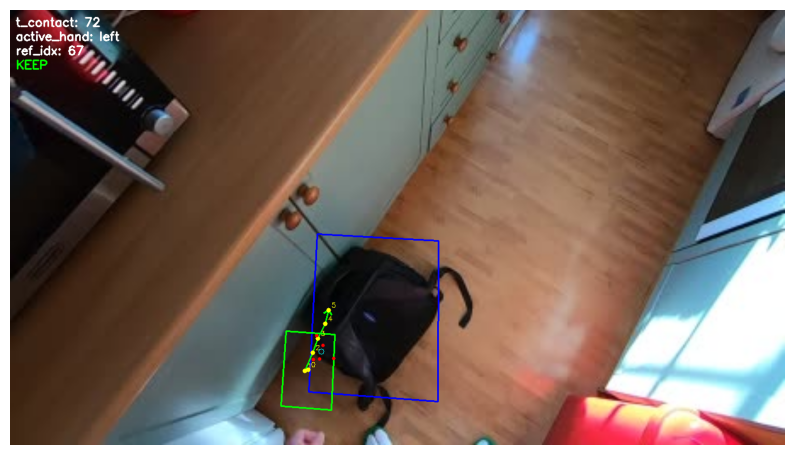

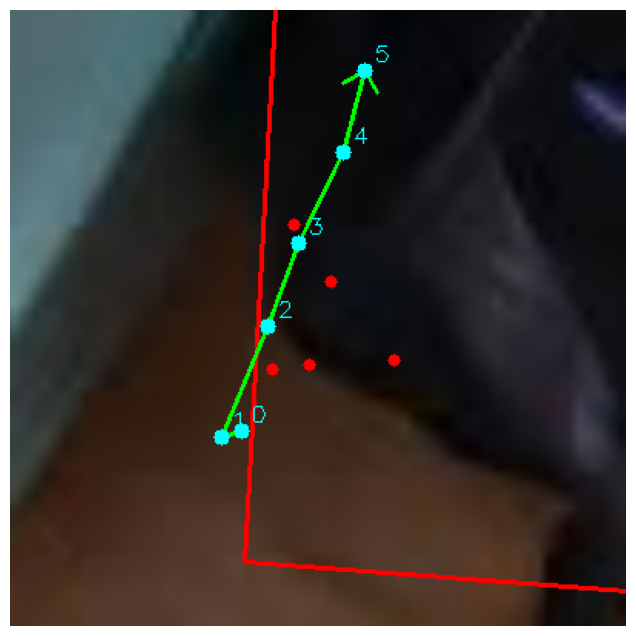

In [5]:
# Cell 3: 单应性矩阵与几何质量门控 (Problem 3 Fixed)
%matplotlib inline
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
from vrbreproduction.problem3_runner import run_problem3_cell3

if 't_contact' not in globals() or 'active_hand' not in globals():
    raise RuntimeError('请先运行 Cell 2，确定当前样本')

print('Cell 3 进入流程帧数: 1')
print('=' * 80)
print('Cell 3 输入状态检查')
print('=' * 80)
print(f'从当前 kernel 读取到: t_contact={t_contact}, active_hand={active_hand}')
print(f'Cell 2 discard={globals().get("discard", None)}, discard_reason={globals().get("discard_reason", None)}')
print(f'contact_means 是否存在: {"contact_means" in globals() and contact_means is not None}')
print(f'contact_covariances 是否存在: {"contact_covariances" in globals() and contact_covariances is not None}')
if "contact_means" not in globals() or contact_means is None:
    print('提示：请先重新运行 Cell 2；手动样本参数只在 Cell 2 执行后才会写入后续变量。')

result = run_problem3_cell3(
    detections=detections,
    t_contact=t_contact,
    active_hand=active_hand,
    contact_means=globals().get('contact_means', None),
    discard=globals().get('discard', False),
    discard_reason=globals().get('discard_reason', None),
    image_dir=Path('data/P01_109_frames'),
    output_dir=Path('outputs'),
)

# 将关键结果写回 notebook 全局变量，便于后续调试
discard = result['discard']
discard_reason = result['discard_reason']
ref_idx = result.get('ref_idx')
H_contact_to_ref = result.get('H_contact_to_ref')
mu_transformed = result.get('mu_transformed')
tau_transformed = result.get('tau_transformed')
object_polygon_ref = result.get('object_polygon_ref')
hand_polygon_ref = result.get('hand_polygon_ref')
contact_centroid = result.get('contact_centroid')
projected_area = result.get('projected_area')
area_ratio = result.get('area_ratio')
inside_count = result.get('inside_count')
centroid_dist = result.get('centroid_dist')
full_overlay_path = result.get('full_overlay_path')
crop_path = result.get('crop_path')
all_pair_stats = result.get('all_pair_stats')

# Notebook 里直接展示输出图片；即使 DISCARD，也不会再抛 SystemExit
if full_overlay_path is not None and Path(full_overlay_path).exists():
    full_img = cv2.cvtColor(cv2.imread(str(full_overlay_path)), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(full_img)
    plt.axis('off')
    plt.show()

if crop_path is not None and Path(crop_path).exists():
    crop_img = cv2.cvtColor(cv2.imread(str(crop_path)), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 8))
    plt.imshow(crop_img)
    plt.axis('off')
    plt.show()


Cell 4 进入流程帧数: 1
Cell 4: Merged Label Heatmap Generation
Cell 4 输入状态检查
  t_contact=72, active_hand=left, ref_idx=67
  discard=False, discard_reason=None
  contact_means: 有
  contact_covariances: 有
  H_contact_to_ref: 有
  mu_transformed: 有
Reference frame: data/P01_109_frames/frame_0000000068.jpg
Image size: 456x256
mu_transformed 坐标系与该图像一致

热图参数:
  heatmap_mode = "covariance"
  merge_method = "sum"
  使用 GMM 权重 = True
  权重值 = [0.09859157 0.09503552 0.15490092 0.1830986  0.46837348]
  covariance_scale = 6.0
  min_sigma_px = 7.0
  max_sigma_px = 40.0

生成 label heatmap...
使用 mu_transformed (5 个中心点)
各模式热图 shape: (5, 256, 456)

各模式信息:
  Mode 1: center=(178.6, 206.0), weight=0.099, sigma_axes=(0.1, 2.9)
  Mode 2: center=(184.2, 197.5), weight=0.095, sigma_axes=(0.9, 3.4)
  Mode 3: center=(180.6, 192.0), weight=0.155, sigma_axes=(1.0, 5.9)
  Mode 4: center=(190.5, 205.1), weight=0.183, sigma_axes=(0.1, 1.9)
  Mode 5: center=(182.2, 205.6), weight=0.468, sigma_axes=(0.8, 8.5)

合并后热图 shape: (256

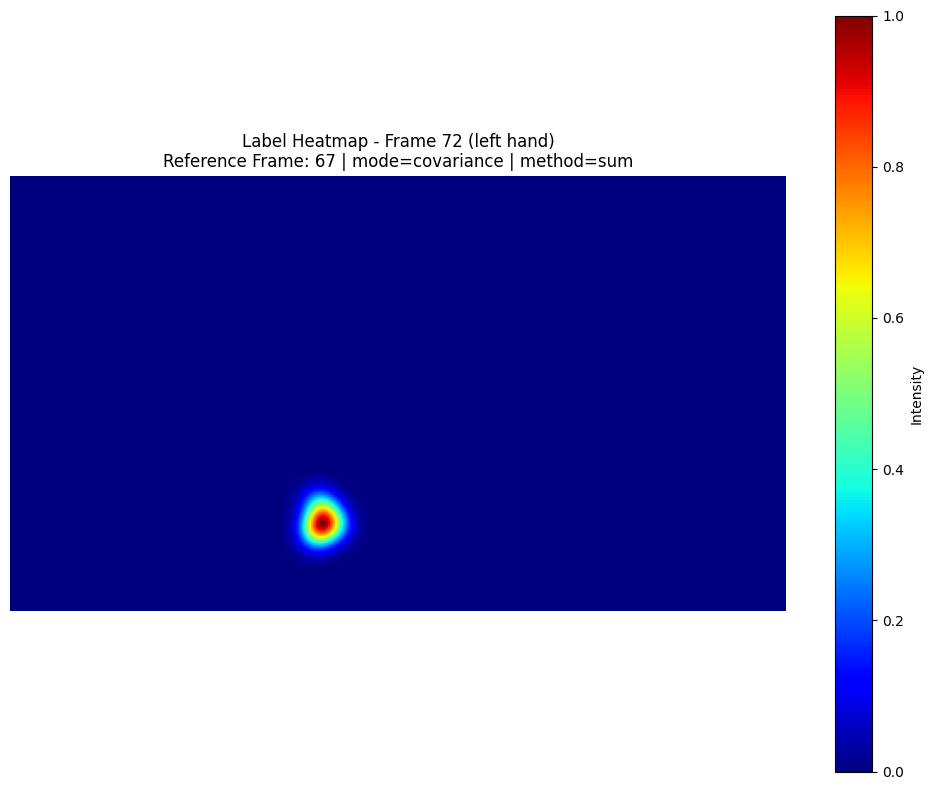

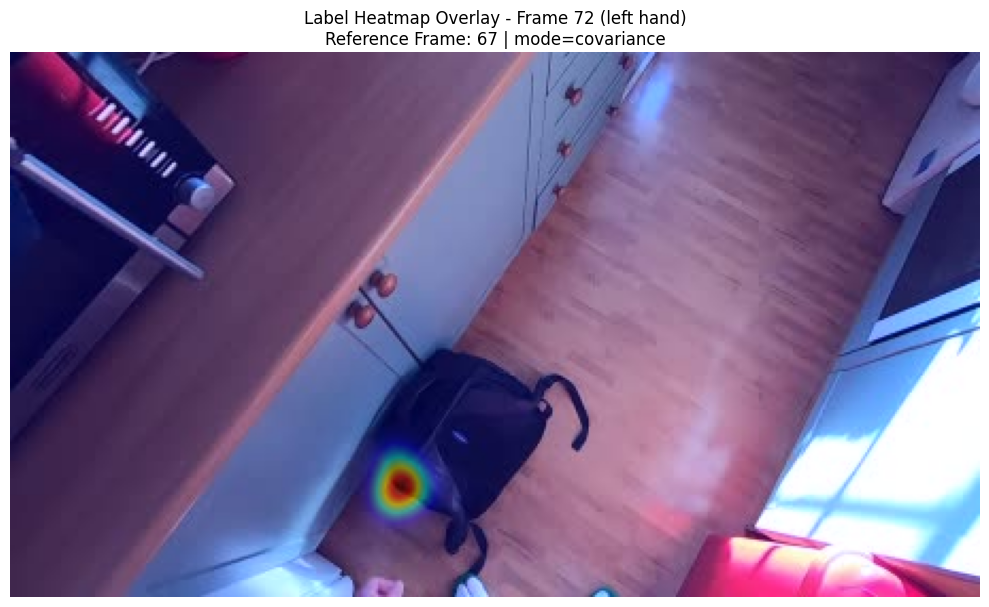


VRB-style arrow:
  anchor=(183.2, 201.2)
  raw_motion=(12.0, -35.1)
  heatmap_radius≈11.9, display_length=14.2
  display_end=(188.1, 187.0)


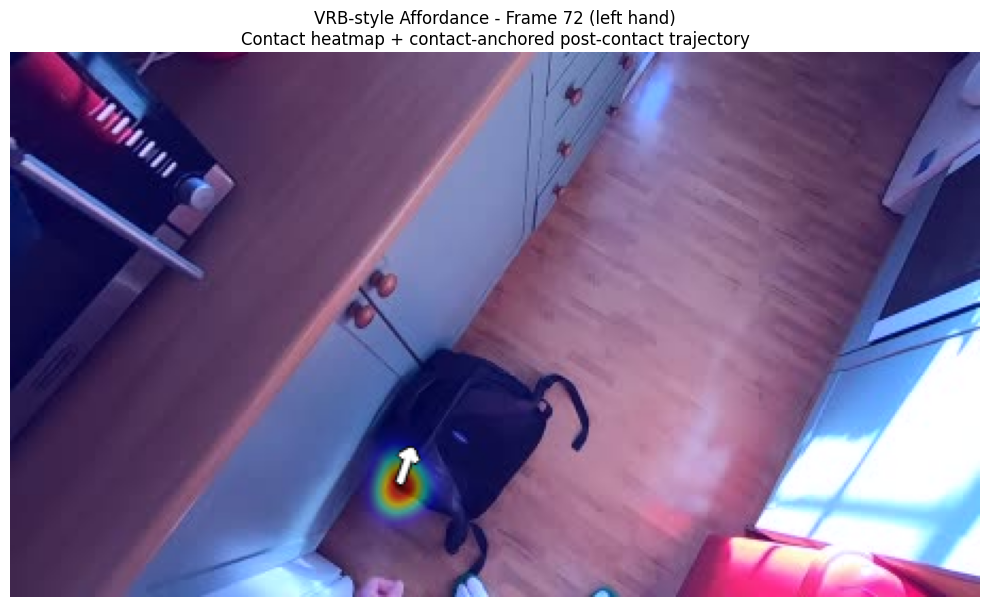

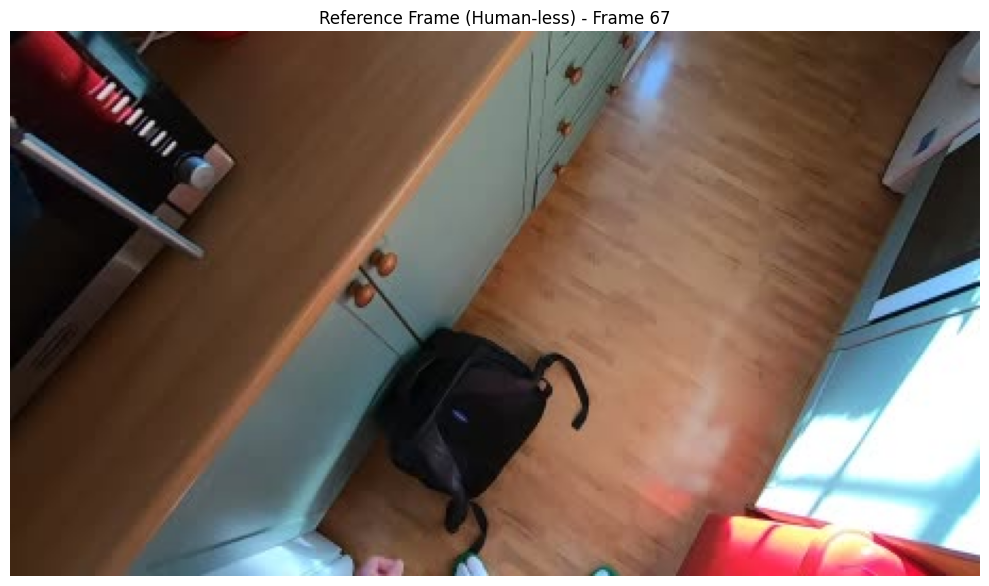


参考帧已保存: outputs/step4_reference_frame.png

Cell 4 总结
样本: frame=72, hand=left, ref_idx=67
生成文件:
  - outputs/step4_label_heatmap_merged.npy
  - outputs/step4_label_heatmap_merged.png
  - outputs/step4_label_heatmap_merged_overlay.png
  - outputs/step4_vrb_style_affordance.png

关键说明:
  1. 热图绘制在 reference frame (frame 67) 上，而非原始接触帧
  2. 使用 mu_transformed 确保热点位置与模型预测一致
  3. heatmap_mode=covariance；covariance 模式会生成椭圆热区
  4. step4_vrb_style_affordance.png 将手/腕轨迹的相对方向锚定到接触热区中心
  5. 可与模型预测 heatmap 进行逐张对比


In [6]:
# Cell 4: 生成 Merged Label Heatmap
# ============================================================
# 功能说明：
#   - 在 reference frame（human-less frame）上生成 label heatmap
#   - 使用 mu_transformed 而非原始 contact_means，确保坐标系一致
#   - 优先使用 GMM covariance 生成椭圆热区，更接近论文/原 demo 的密度可视化
#   - 与模型预测 heatmap 进行直接对比
# ============================================================
%matplotlib inline
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# 导入 label heatmap 工具函数
from vrbreproduction.label_heatmap_utils import (
    build_label_heatmaps,
    draw_vrb_style_affordance_overlay,
    merge_label_heatmaps,
    overlay_heatmap_on_rgb,
    save_label_heatmap_outputs,
    transform_covariances_by_homography,
)

print('Cell 4 进入流程帧数: 1')
print('=' * 80)
print('Cell 4: Merged Label Heatmap Generation')
print('=' * 80)

print('Cell 4 输入状态检查')
print(f'  t_contact={globals().get("t_contact", None)}, active_hand={globals().get("active_hand", None)}, ref_idx={globals().get("ref_idx", None)}')
print(f'  discard={globals().get("discard", None)}, discard_reason={globals().get("discard_reason", None)}')
print(f'  contact_means: {"有" if "contact_means" in globals() and contact_means is not None else "无"}')
print(f'  contact_covariances: {"有" if "contact_covariances" in globals() and contact_covariances is not None else "无"}')
print(f'  H_contact_to_ref: {"有" if "H_contact_to_ref" in globals() and H_contact_to_ref is not None else "无"}')
print(f'  mu_transformed: {"有" if "mu_transformed" in globals() and mu_transformed is not None else "无"}')

# ============================================================
# Step 1: 前置变量检查
# ============================================================
# 必需变量：discard, discard_reason, ref_idx, mu_transformed
# 可选变量：contact_weights, contact_covariances, H_contact_to_ref

# 检查 discard 状态
if 'discard' in globals() and discard:
    print('当前样本已 discard，跳过 merged label heatmap 生成')
    print(f'丢弃原因: {discard_reason}')
    print('\n如需生成 heatmap，请使用 KEEP 样本（未被 Cell 2/3 丢弃的样本）')
    label_heatmap_generated = False
else:
    label_heatmap_generated = True

# 检查必需变量
if label_heatmap_generated:
    if 'mu_transformed' not in globals() or mu_transformed is None:
        print('缺少 mu_transformed，无法在 reference frame 上绘制 label heatmap')
        print('mu_transformed 应由 Cell 3 的 run_problem3_cell3() 生成')
        label_heatmap_generated = False
    elif 'ref_idx' not in globals() or ref_idx is None:
        print('缺少 ref_idx，无法读取 reference frame')
        label_heatmap_generated = False

# ============================================================
# Step 2: 读取 Reference Frame 图像
# ============================================================
# 关键：必须使用 Cell 3 的 ref_idx，确保坐标系与 mu_transformed 一致
# 禁止在原始 contact frame (t_contact) 上绘制

if label_heatmap_generated:
    image_dir = Path('data/P01_109_frames')
    ref_path = image_dir / f'frame_{ref_idx + 1:010d}.jpg'
    ref_img = cv2.imread(str(ref_path))
    if ref_img is None:
        raise FileNotFoundError(f'找不到 reference frame 图像: {ref_path}')
    ref_img_rgb = cv2.cvtColor(ref_img, cv2.COLOR_BGR2RGB)
    h_img, w_img = ref_img_rgb.shape[:2]
    print(f'Reference frame: {ref_path}')
    print(f'Image size: {w_img}x{h_img}')
    print('mu_transformed 坐标系与该图像一致')

# ============================================================
# Step 3: 设置热图生成参数
# ============================================================

if label_heatmap_generated:
    # heatmap_mode:
    # - "covariance": 使用 GMM covariance 生成椭圆高斯热区（默认）
    # - "isotropic": 使用固定 sigma 的圆形高斯热区（旧实现）
    heatmap_mode = 'covariance'

    # covariance_scale 控制椭圆整体扩散程度。
    # 原始 GMM covariance 来自接触点边缘，视觉上可能偏紧；适当放大更接近展示图。
    covariance_scale = 6.0
    min_sigma_px = 7.0
    max_sigma_px = 40.0

    # isotropic fallback 参数：只有缺少 covariance/H 时才使用
    sigma_px = 12.0

    # merge_method: 合并方式
    # - "sum": 累加各模式强度，更接近密度图/论文示意图，多个中心会自然连成长形区域
    # - "max": 各模式取最大，适合检查每个 mode 的位置
    merge_method = 'sum'

    # 是否使用 GMM 权重
    # True: 使用 contact_weights 缩放各模式热图振幅
    # False: 所有模式等权重
    use_weights = True if 'contact_weights' in globals() and contact_weights is not None else False
    weights = contact_weights if use_weights else None

    use_covariances = (
        heatmap_mode == 'covariance'
        and 'contact_covariances' in globals()
        and contact_covariances is not None
        and 'contact_means' in globals()
        and contact_means is not None
        and 'H_contact_to_ref' in globals()
        and H_contact_to_ref is not None
    )

    if heatmap_mode == 'covariance' and not use_covariances:
        print('缺少 contact_covariances/contact_means/H_contact_to_ref，自动退回 isotropic Gaussian')
        heatmap_mode = 'isotropic'

    covariances_ref = None
    if use_covariances:
        covariances_ref = transform_covariances_by_homography(
            contact_covariances,
            contact_means,
            H_contact_to_ref,
        )

    print(f'\n热图参数:')
    print(f'  heatmap_mode = "{heatmap_mode}"')
    print(f'  merge_method = "{merge_method}"')
    print(f'  使用 GMM 权重 = {use_weights}')
    if use_weights:
        print(f'  权重值 = {weights}')
    if heatmap_mode == 'covariance':
        print(f'  covariance_scale = {covariance_scale}')
        print(f'  min_sigma_px = {min_sigma_px}')
        print(f'  max_sigma_px = {max_sigma_px}')
    else:
        print(f'  sigma_px = {sigma_px} (圆形 fallback 热区扩散半径)')

# ============================================================
# Step 4: 生成单模式热图
# ============================================================
# 使用 mu_transformed 而非 contact_means 的原因：
#   - mu_transformed 已通过单应性矩阵变换到 reference frame 坐标系
#   - covariance 也通过同一个 homography 的局部 Jacobian 变换到 reference frame
#   - 确保热点绘制在正确的位置（与模型预测图对齐）

if label_heatmap_generated:
    print(f'\n生成 label heatmap...')
    print(f'使用 mu_transformed ({len(mu_transformed)} 个中心点)')

    # 构建每模式热图: shape=[K, H, W]
    per_mode_heatmaps = build_label_heatmaps(
        image_shape=(h_img, w_img),
        centers_xy=mu_transformed,
        sigma_px=sigma_px,
        weights=weights,
        normalize_each=True,
        covariances_xy=covariances_ref,
        covariance_scale=covariance_scale,
        min_sigma_px=min_sigma_px,
        max_sigma_px=max_sigma_px,
    )
    print(f'各模式热图 shape: {per_mode_heatmaps.shape}')

    # 打印每个模式的中心点、权重和椭圆主轴
    print(f'\n各模式信息:')
    for k in range(len(mu_transformed)):
        cx, cy = mu_transformed[k]
        w = weights[k] if use_weights else 1.0 / len(mu_transformed)
        if covariances_ref is not None:
            eigvals = np.linalg.eigvalsh(covariances_ref[k] * covariance_scale)
            sigmas = np.sqrt(np.maximum(eigvals, 0.0))
            print(
                f'  Mode {k+1}: center=({cx:.1f}, {cy:.1f}), '
                f'weight={w:.3f}, sigma_axes=({sigmas[0]:.1f}, {sigmas[1]:.1f})'
            )
        else:
            print(f'  Mode {k+1}: center=({cx:.1f}, {cy:.1f}), weight={w:.3f}')

# ============================================================
# Step 5: 合并热图
# ============================================================

if label_heatmap_generated:
    # 合并为单张热图: shape=[H, W]
    merged_heatmap = merge_label_heatmaps(
        per_mode_heatmaps=per_mode_heatmaps,
        merge_method=merge_method,
        normalize_output=True
    )
    print(f'\n合并后热图 shape: {merged_heatmap.shape}')
    print(f'热图值范围: [{merged_heatmap.min():.4f}, {merged_heatmap.max():.4f}]')

# ============================================================
# Step 6: 保存与展示
# ============================================================

if label_heatmap_generated:
    output_dir = Path('outputs')

    # 保存输出文件
    output_paths = save_label_heatmap_outputs(
        merged_heatmap=merged_heatmap,
        ref_image=ref_img_rgb,
        output_dir=output_dir,
        prefix='step4_label_heatmap',
        sigma_px=sigma_px,
        merge_method=merge_method,
        use_weights=use_weights,
        heatmap_mode=heatmap_mode,
        t_contact=t_contact if 't_contact' in globals() else None,
        active_hand=active_hand if 'active_hand' in globals() else None,
        ref_idx=ref_idx
    )

    # 在 Notebook 中展示
    print('\n' + '=' * 60)
    print('可视化结果')
    print('=' * 60)

    # 1. 纯热图（伪彩色）
    plt.figure(figsize=(10, 8))
    plt.imshow(merged_heatmap, cmap='jet')
    plt.colorbar(label='Intensity')
    plt.title(f'Label Heatmap - Frame {t_contact} ({active_hand} hand)\n'
              f'Reference Frame: {ref_idx} | mode={heatmap_mode} | method={merge_method}')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(output_dir / 'step4_label_heatmap_display.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 2. 叠加效果图
    overlay_img = overlay_heatmap_on_rgb(
        ref_img_rgb,
        merged_heatmap,
        alpha=0.45,
        colormap=cv2.COLORMAP_JET
    )
    plt.figure(figsize=(10, 8))
    plt.imshow(overlay_img)
    plt.title(f'Label Heatmap Overlay - Frame {t_contact} ({active_hand} hand)\n'
              f'Reference Frame: {ref_idx} | mode={heatmap_mode}')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # 3. VRB-style 最终 affordance 可视化
    # 语义对齐论文/demo：heatmap 表示接触区域，白色箭头从接触区域出发，方向来自 post-contact hand/wrist trajectory。
    if 'contact_centroid' in globals() and contact_centroid is not None:
        arrow_anchor_xy = contact_centroid
    else:
        arrow_anchor_xy = np.asarray(mu_transformed, dtype=np.float32).mean(axis=0)

    tau_points_for_arrow = globals().get('tau_transformed', [])
    vrb_style_img, arrow_info = draw_vrb_style_affordance_overlay(
        ref_img_rgb,
        merged_heatmap,
        tau_points_for_arrow,
        arrow_anchor_xy,
        heatmap_alpha=0.45,
        colormap=cv2.COLORMAP_JET,
        arrow_length_px=None,
        arrow_length_heatmap_ratio=1.2,
        arrow_width_px=None,
        source_step='last',
    )
    vrb_style_path = output_dir / 'step4_vrb_style_affordance.png'
    cv2.imwrite(str(vrb_style_path), cv2.cvtColor(vrb_style_img, cv2.COLOR_RGB2BGR))
    if arrow_info is not None:
        print('\nVRB-style arrow:')
        print(f'  anchor=({arrow_info["start_xy"][0]:.1f}, {arrow_info["start_xy"][1]:.1f})')
        print(f'  raw_motion=({arrow_info["raw_motion"][0]:.1f}, {arrow_info["raw_motion"][1]:.1f})')
        radius_info = arrow_info['estimated_heatmap_radius_px']
        radius_text = 'n/a' if radius_info is None else f'{radius_info:.1f}'
        print(f'  heatmap_radius≈{radius_text}, display_length={arrow_info["display_length_px"]:.1f}')
        print(f'  display_end=({arrow_info["end_xy"][0]:.1f}, {arrow_info["end_xy"][1]:.1f})')
    else:
        print('\nVRB-style arrow 未生成：有效轨迹点不足或运动幅度过小')

    plt.figure(figsize=(10, 8))
    plt.imshow(vrb_style_img)
    plt.title(f'VRB-style Affordance - Frame {t_contact} ({active_hand} hand)\n'
              f'Contact heatmap + contact-anchored post-contact trajectory')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # 4. 显示参考帧（对照）
    plt.figure(figsize=(10, 8))
    plt.imshow(ref_img_rgb)
    plt.title(f'Reference Frame (Human-less) - Frame {ref_idx}')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # 保存 reference frame 用于后续对比
    ref_frame_path = output_dir / 'step4_reference_frame.png'
    cv2.imwrite(str(ref_frame_path), cv2.cvtColor(ref_img_rgb, cv2.COLOR_RGB2BGR))
    print(f'\n参考帧已保存: {ref_frame_path}')

else:
    print('\n跳过 heatmap 生成（样本已丢弃或缺少必要变量）')
    print('后续可使用 inference.py 生成的模型预测 heatmap 与本标签热图进行对比')

# ============================================================
# 总结
# ============================================================
print('\n' + '=' * 80)
print('Cell 4 总结')
print('=' * 80)
if label_heatmap_generated:
    print(f'样本: frame={t_contact}, hand={active_hand}, ref_idx={ref_idx}')
    print(f'生成文件:')
    print(f'  - {output_paths["npy_path"]}')
    print(f'  - {output_paths["png_path"]}')
    print(f'  - {output_paths["overlay_path"]}')
    print(f'  - {vrb_style_path}')
    print(f'\n关键说明:')
    print(f'  1. 热图绘制在 reference frame (frame {ref_idx}) 上，而非原始接触帧')
    print(f'  2. 使用 mu_transformed 确保热点位置与模型预测一致')
    print(f'  3. heatmap_mode={heatmap_mode}；covariance 模式会生成椭圆热区')
    print(f'  4. step4_vrb_style_affordance.png 将手/腕轨迹的相对方向锚定到接触热区中心')
    print(f'  5. 可与模型预测 heatmap 进行逐张对比')
else:
    print('未生成 heatmap，请检查样本状态')


In [7]:
# Cell 5: 前 500 帧完整 pipeline 保留数量统计
# ============================================================
# 只打印数量：每一阶段进入多少帧、保留多少帧、不能用多少帧。
# 完整 pipeline 出结果 = 成功通过 Cell 4 label heatmap 门控。
# ============================================================

from pathlib import Path

from vrbreproduction.pipeline_retention import run_pipeline_retention_scan

batch_scan_limit = 500
pipeline_retention_result = run_pipeline_retention_scan(
    detections=detections,
    scan_limit=batch_scan_limit,
    image_dir=Path('data/P01_109_frames'),
    output_dir=Path('outputs/pipeline_retention_debug'),
    output_json_path=Path('outputs/pipeline_retention_500.json'),
    contact_extraction_config=contact_extraction_config,
    precomputed_cell1_valid=filtered_pipeline_samples,
    precomputed_cell1_rejected=scan_failures,
    precomputed_cell1_summary=scan_summary,
    quiet=True,
)

print('=' * 80)
print('前 500 帧完整 pipeline 数量统计')
print('=' * 80)
for row in pipeline_retention_result['summary']:
    print('{cell} 进入流程帧数: {entered_frames}, 保留可用: {kept_frames}, 不能用: {discarded_frames}'.format(**row))
print('完整 pipeline 出结果帧数: {}'.format(pipeline_retention_result['full_pipeline_frames']))
print('统计结果 JSON: outputs/pipeline_retention_500.json')


前 500 帧完整 pipeline 数量统计
Cell 1-test 进入流程帧数: 500, 保留可用: 375, 不能用: 125
Cell 2 进入流程帧数: 375, 保留可用: 367, 不能用: 8
Cell 3 进入流程帧数: 367, 保留可用: 11, 不能用: 356
Cell 4 进入流程帧数: 11, 保留可用: 11, 不能用: 0
完整 pipeline 出结果帧数: 11
统计结果 JSON: outputs/pipeline_retention_500.json
